In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeManilaV2
#from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Operator, SparsePauliOp

In [180]:
x0 = 0
y0 = 0.2

step_size = 0.1

xn = 0.4

In [181]:
X = np.arange(x0, xn + step_size, step_size)

In [182]:
#z = np.log(np.abs(-y))
h = np.log(np.abs(step_size/6))

In [162]:
#Fake Backend
backend = FakeManilaV2()

In [163]:
estimator = Estimator(backend)

In [183]:
qc = QuantumCircuit(1)

qc.h(0)

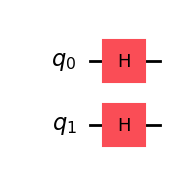

In [184]:
qc2 = QuantumCircuit(2)

qc2.h([0,1])
#qc2.x([0 , 1])

qc2.draw('mpl')

In [185]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_psi = pm.run(qc)

pm2 = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_psi2 = pm2.run(qc2)

In [167]:
def func(x, y):
    
    return -y

In [ ]:
y_pred = [y0]
y = y0

for x in X[:-1]:

    k1 = func(x, y)

    k2 = func(x + (step_size/2), y + (step_size * k1/2))

    k3 = func(x + (step_size/2), y + (step_size * k2/2))

    k4 = func(x + step_size, y + (step_size * k3))

    #print('k', k1, k2, k3, k4)

    #Add all K
    sum_k = np.array([[k1, 0, 0, 0],
                    [0, 2*k2, 0, 0],
                    [0, 0, 2*k3, 0],
                    [0, 0, 0, k4]])

    ops0 = Operator(sum_k)
    h_s = SparsePauliOp.from_operator(ops0)

    isa_observables0 = h_s.apply_layout(isa_psi2.layout)
    job0 = estimator.run([(isa_psi2, isa_observables0)], precision=0.001)

    job_result0 = job0.result()[0] # It will block until the job finishes.
    expv0 = job_result0.data.evs
    sm = 4*expv0

    #print("sum", sm)

    s = np.log(np.abs(sm))


    #Multiplying h with K
    h_m = np.array([[h, 0],
                    [0, s]])

    opm = Operator(h_m)
    h_m = SparsePauliOp.from_operator(opm)

    isa_observables1 = h_m.apply_layout(isa_psi.layout)
    job1 = estimator.run([(isa_psi, isa_observables1)], precision=0.001 )

    job_result1 = job1.result()[0] 
    expv1 = job_result1.data.evs
    m = np.exp(2*expv1) * np.sign(sm)

    #print('mul', m)

    #Adding to old value
    h_s2 = np.array([[y, 0],
                     [0, m]])

    ops3 = Operator(h_s2)
    h_s2 = SparsePauliOp.from_operator(ops3)

    isa_observables2 = h_s2.apply_layout(isa_psi.layout)
    job2 = estimator.run([(isa_psi, isa_observables2)], precision=0.001)

    job_result2 = job2.result()[0] # It will block until the job finishes.
    expv2 = job_result2.data.evs
    ans = 2*expv2

    #print('ans', ans)
    y = ans
    #print("y", np.round(y, 2))
    y_pred.append(y)

    


In [176]:
import math

# step size
h = 0.1

# x values from 0 to 0.5
x_vals = X

# define the ODE: dy/dx = -y
def f(x, y):
    return -y

# initial condition
y = 0.2
y_rk4 = [y]

# RK4 loop
for i in range(len(x_vals)-1):
    x = x_vals[i]

    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)

    y = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    y_rk4.append(y)

y_true = [0.2 * math.exp(-x) for x in x_vals]

# print results
for x, yr, yt in zip(x_vals, y_rk4, y_true):
    print(f"x = {x}, RK4 = {yr:.6f}, True = {yt:.6f}")

x = 0.0, RK4 = 0.200000, True = 0.200000
x = 0.1, RK4 = 0.180968, True = 0.180967
x = 0.2, RK4 = 0.163746, True = 0.163746
x = 0.30000000000000004, RK4 = 0.148164, True = 0.148164
x = 0.4, RK4 = 0.134064, True = 0.134064


In [187]:
print(X, y_pred, y_rk4)

[0.  0.1 0.2 0.3 0.4] [0.2, np.float64(0.18097162165744737), np.float64(0.16342687614711207), np.float64(0.14800891713365005), np.float64(0.13383086270346634)] [0.2, 0.1809675, 0.16374618028125001, 0.14816368440023556, 0.13406405778349814]


In [188]:
import pandas as pd

df = pd.DataFrame({
    "x": X,
    "y_pred": y_pred,
    "y_rk4": y_rk4
})
print(df)

     x    y_pred     y_rk4
0  0.0  0.200000  0.200000
1  0.1  0.180972  0.180968
2  0.2  0.163427  0.163746
3  0.3  0.148009  0.148164
4  0.4  0.133831  0.134064


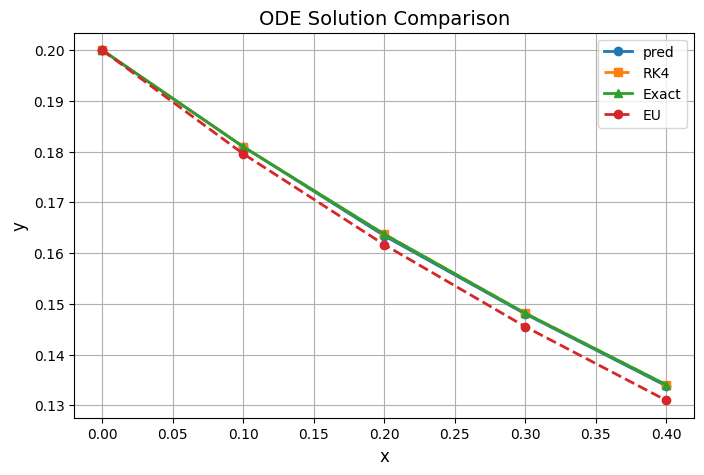

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(X, y_pred, 'o-', linewidth=2, markersize=6, label="pred")
plt.plot(X, y_rk4, 's--', linewidth=2, markersize=6, label="RK4")
plt.plot(X, y_true, '^-', linewidth=2, markersize=6, label="Exact")
plt.plot(X, y_pred_eu, 'o--', linewidth=2, markersize=6, label="EU")

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("ODE Solution Comparison", fontsize=14)

plt.legend()
plt.grid(True)

plt.show()

In [191]:
import pickle

with open("data.pkl", "rb") as f:
    data = pickle.load(f)


In [193]:
y_pred_eu = data["y_pred_eu"]

In [157]:
mse = sum((a - b)**2 for a, b in zip(y_pred, y_true)) / len(y_pred)
print(mse)

2.0078132574479881e-07


In [195]:
mse2 = sum((a - b)**2 for a, b in zip(y_pred_eu, y_true)) / len(y_pred)
print(mse2)

4.552127719695576e-06
